# Section 6 v2 — Sentiment rebuild: domain scoring, high-frequency attention, scorer validation

Thin driver notebook: all logic lives in `src/sentiment/`. Supersedes the original Section 6 notebook's alarm index (kept in place at `notebooks/6_sentiment.ipynb` for reference) with three fixes made *before* any new data was added, per the build brief:

1. **Domain scoring, not VADER.** The original index used VADER (social-media-tuned valence), which barely fires on regulator prose, and was multiplicative (`mentions x negativity`), which zeroes out any report with heavy coverage but non-negative measured tone. The rebuilt index (`src/sentiment/scoring.py`, `analysis_alarm_v2.py`) is additive and z-scored within institution, using Loughran-McDonald negative/uncertainty rates plus a hand-curated vulnerability lexicon (`config.VULNERABILITY_STEMS`). Result: **37 of 40 reports scored exactly zero under the old index; the rebuilt index has real variation across all of them** (see the ledger below).
2. **The LM master dictionary download, previously blocked, is resolved.** The SRAF landing page links a Google Drive share, not a client-rendered file (`src/common/text.py:fetch_lm_dictionary`) — discovered by re-reading the actual page source, not re-assuming the earlier finding.
3. **A second, independent scorer** (a fixed-prompt LLM rubric, temperature 0, cached by input hash — same stub pattern as `src/common/entity.py`'s `llm_tiebreak_cached`) cross-validates a hand-scored sample of sections (`analysis_scorer_validation.py`).

**New corpora**: Bank of England Financial Stability Reports (`scrape_regulators_v2.py`) join the existing Fed/BIS/ECB corpus. Google News RSS + yfinance ticker news (`scrape_news_rss.py`, `scrape_yf_news.py`) form a headline-based attention/tone backbone, standing in for **GDELT**, which is fully implemented (`scrape_gdelt.py`) but persistently rate-limited (HTTP 429) from this project's sandboxed network even with full exponential backoff — logged in `docs/excluded_sources.md`, not silently worked around. The same headline corpus is classified for CLO new-issue pricing announcements (`scrape_pressreleases.py`).

**Not implemented this pass** (documented gaps, not silent drops): FSOC/OFR annual reports, congressional testimony (govinfo.gov), Fed/BoE speech archives, conference-agenda topic drift, podcast corpora, SSRN/RePEc (arXiv only). See `docs/excluded_sources.md`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.sentiment import (
    scrape_regulators_v2, scrape_gdelt, scrape_news_rss, scrape_yf_news, scrape_pressreleases,
    scrape_stocktwits, scrape_ssrn_arxiv,
    scoring, analysis_alarm_v2, analysis_attention_tone, analysis_scorer_validation,
    viz_alarm_v2, viz_attention, viz_validation,
    ledger,
)


/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_regulators_v2.run()   # Bank of England FSRs
    scrape_gdelt.run()           # rate-limited from this environment; degrades gracefully
    scrape_news_rss.run()
    scrape_yf_news.run()
    scrape_pressreleases.run()   # classifies news_headlines.parquet, no new network calls
    scrape_stocktwits.run()
    scrape_ssrn_arxiv.run()


## Analysis (interim -> final)

In [3]:
alarm_v2 = analysis_alarm_v2.run()
attention_tone = analysis_attention_tone.run()
scorer_validation = analysis_scorer_validation.run()


## Viz (final -> figures/)

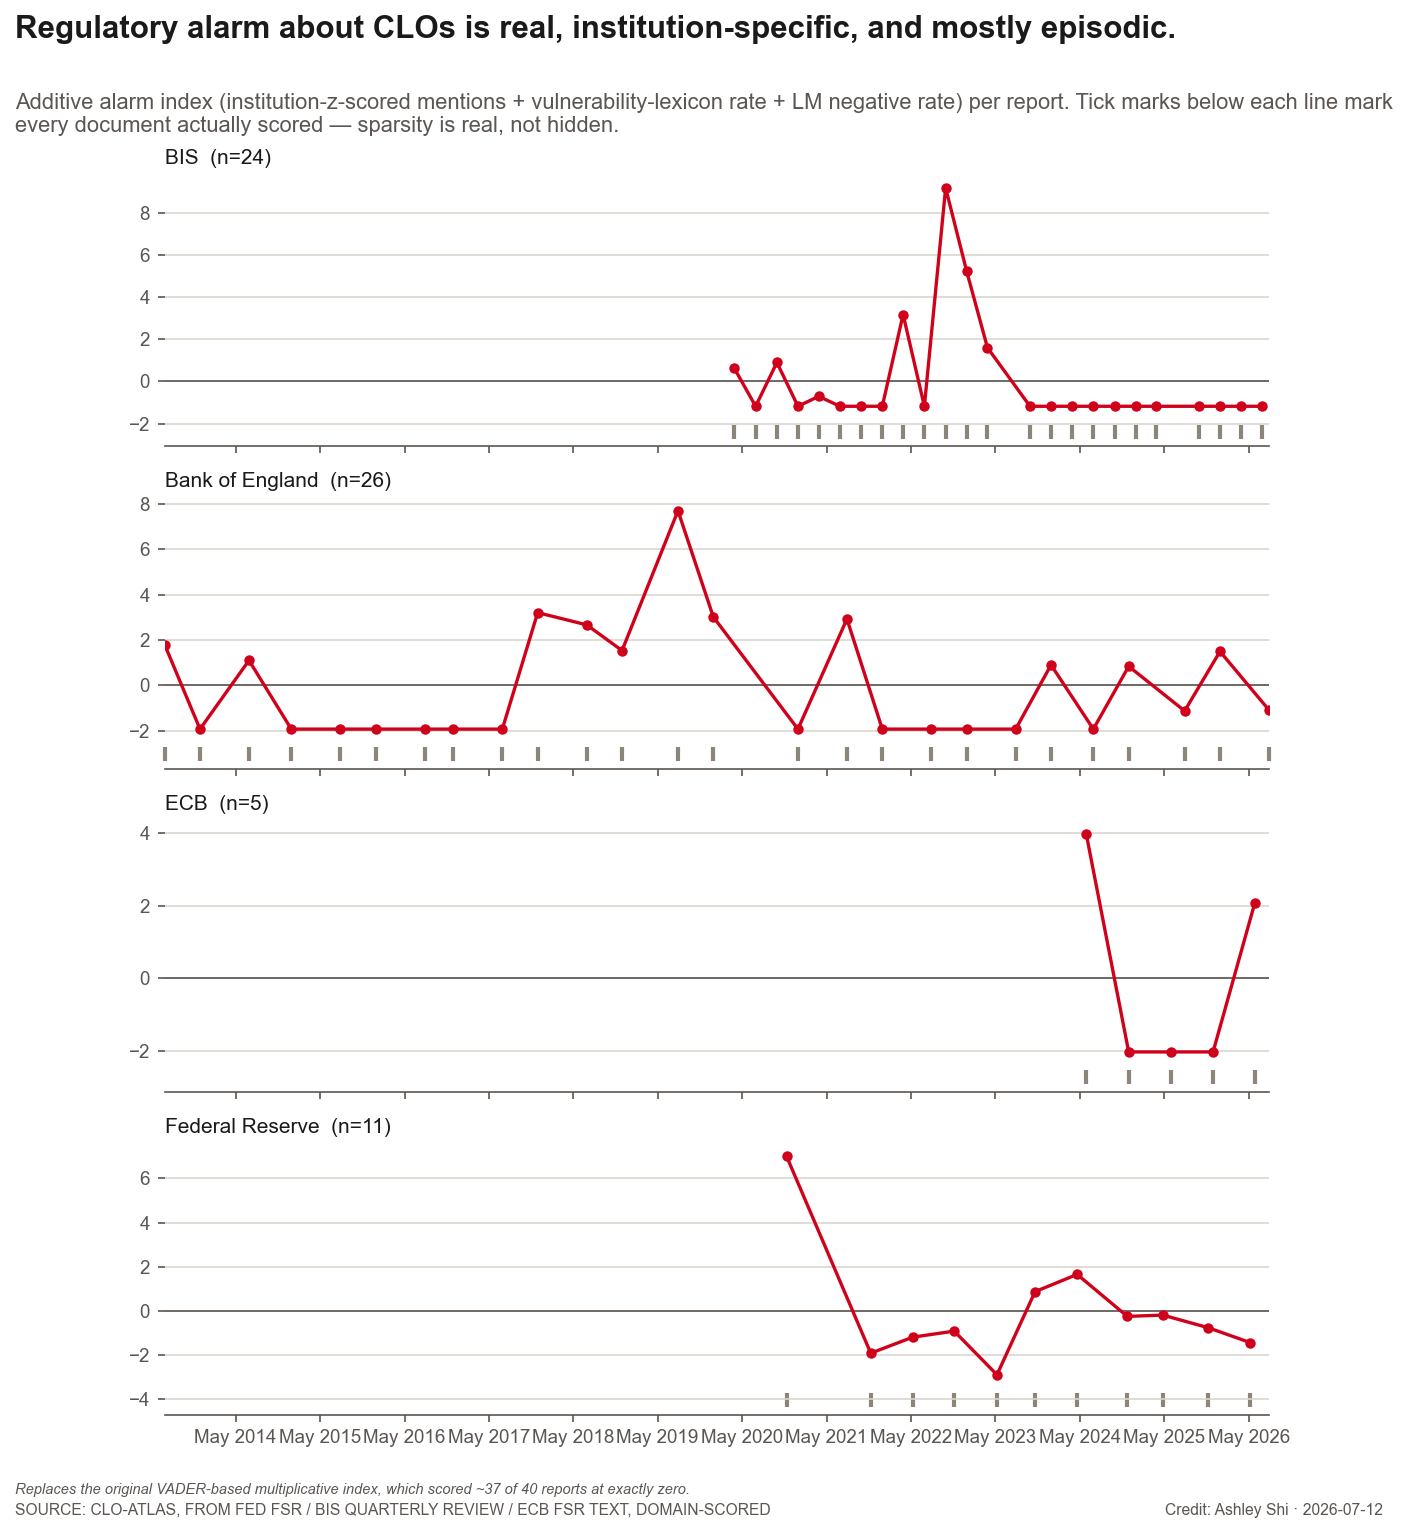

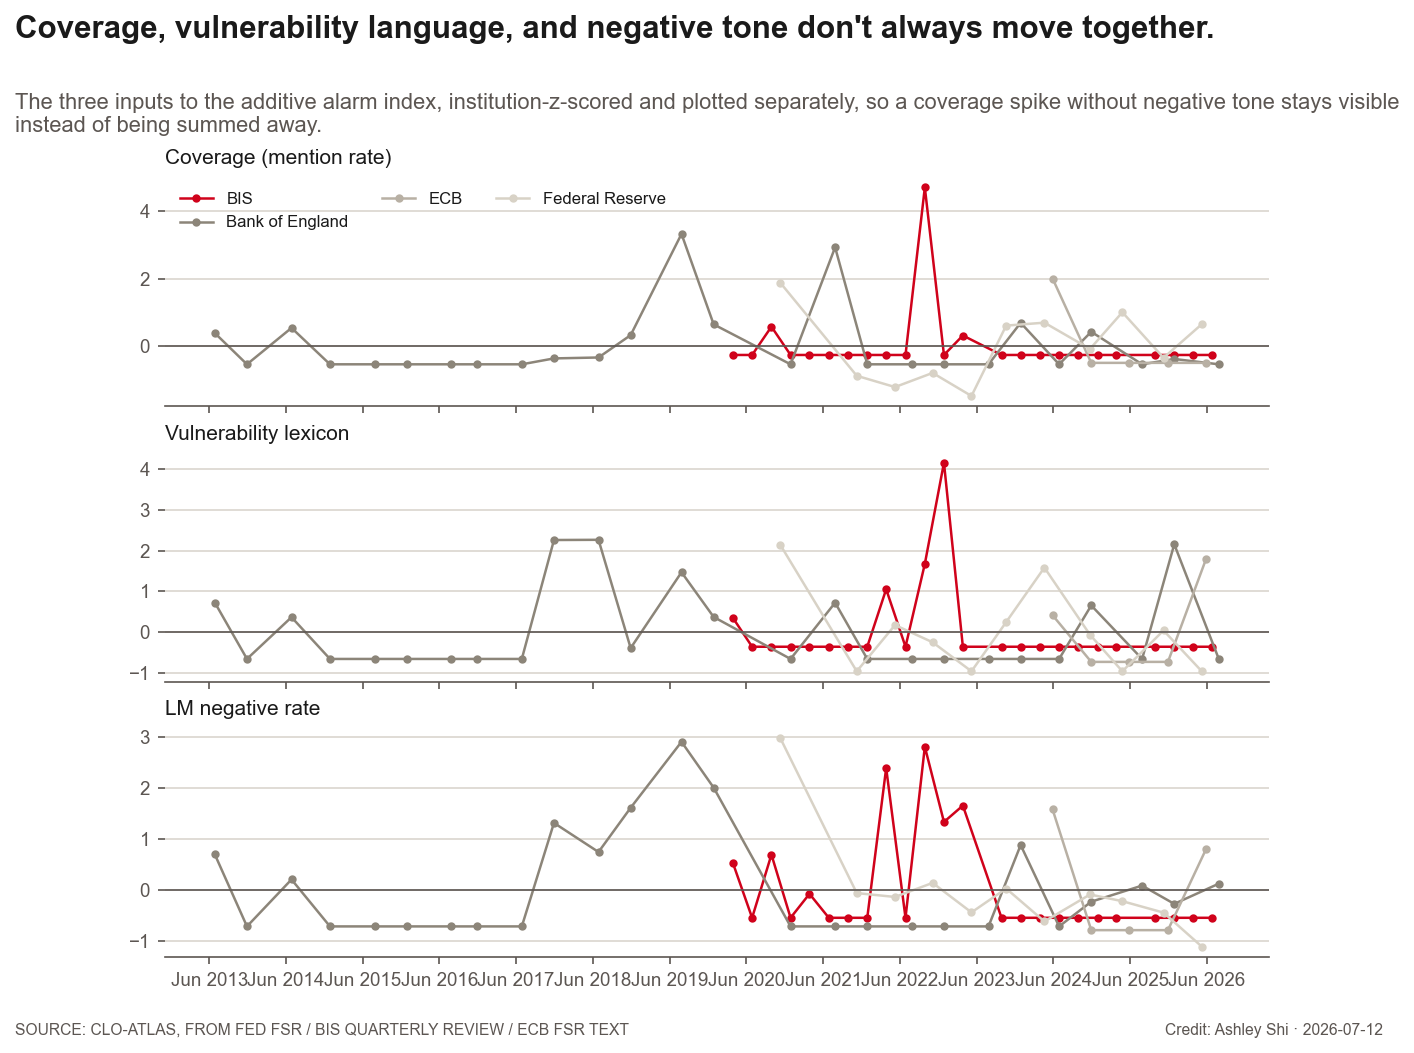

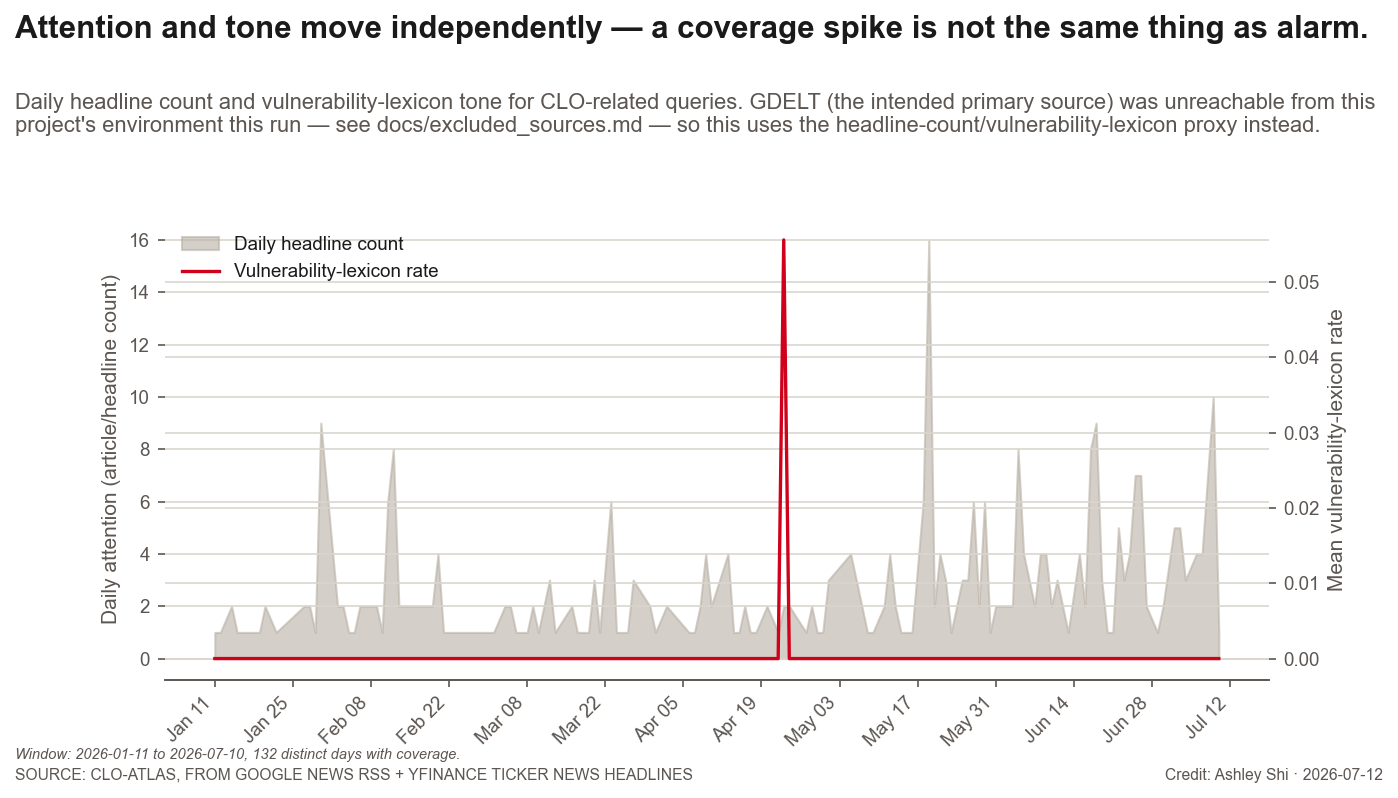

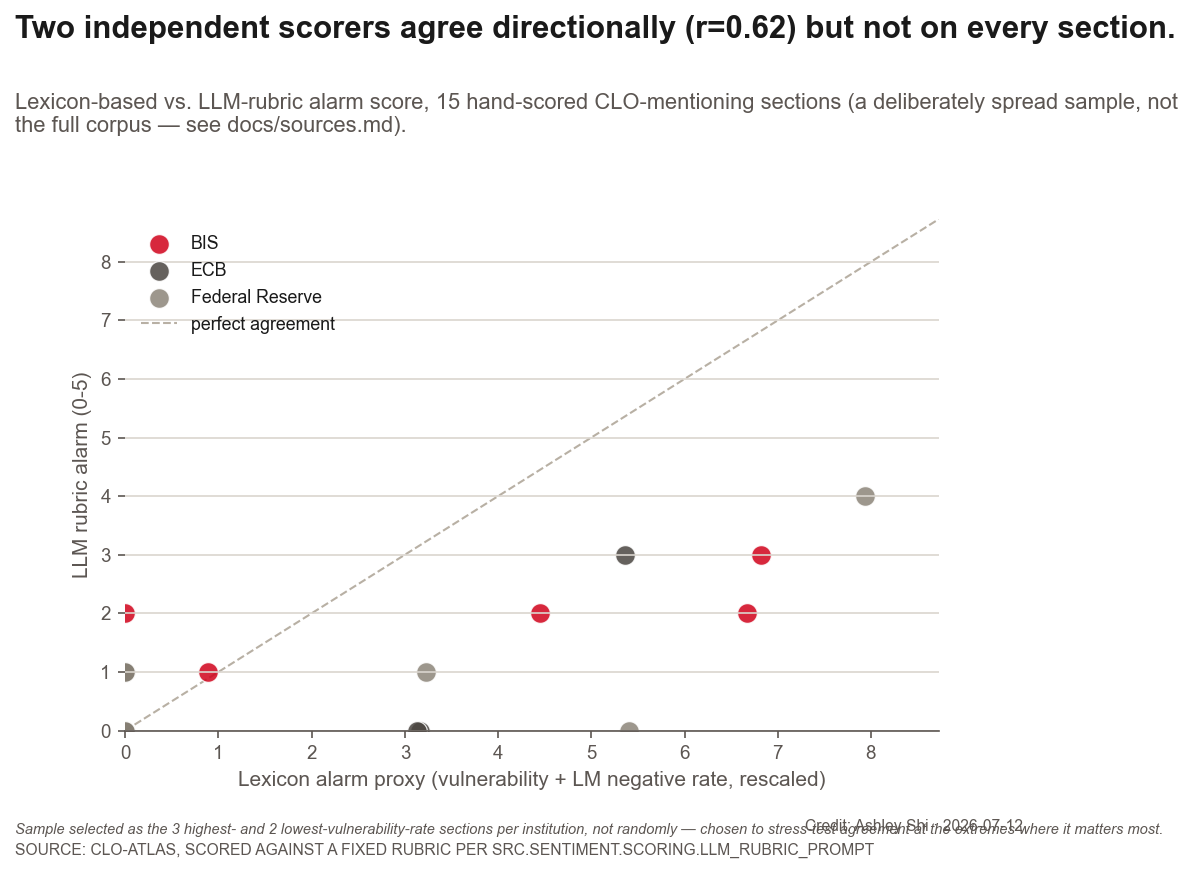

In [4]:
viz_alarm_v2.run()
viz_attention.run()
viz_validation.run()


## Exhibits

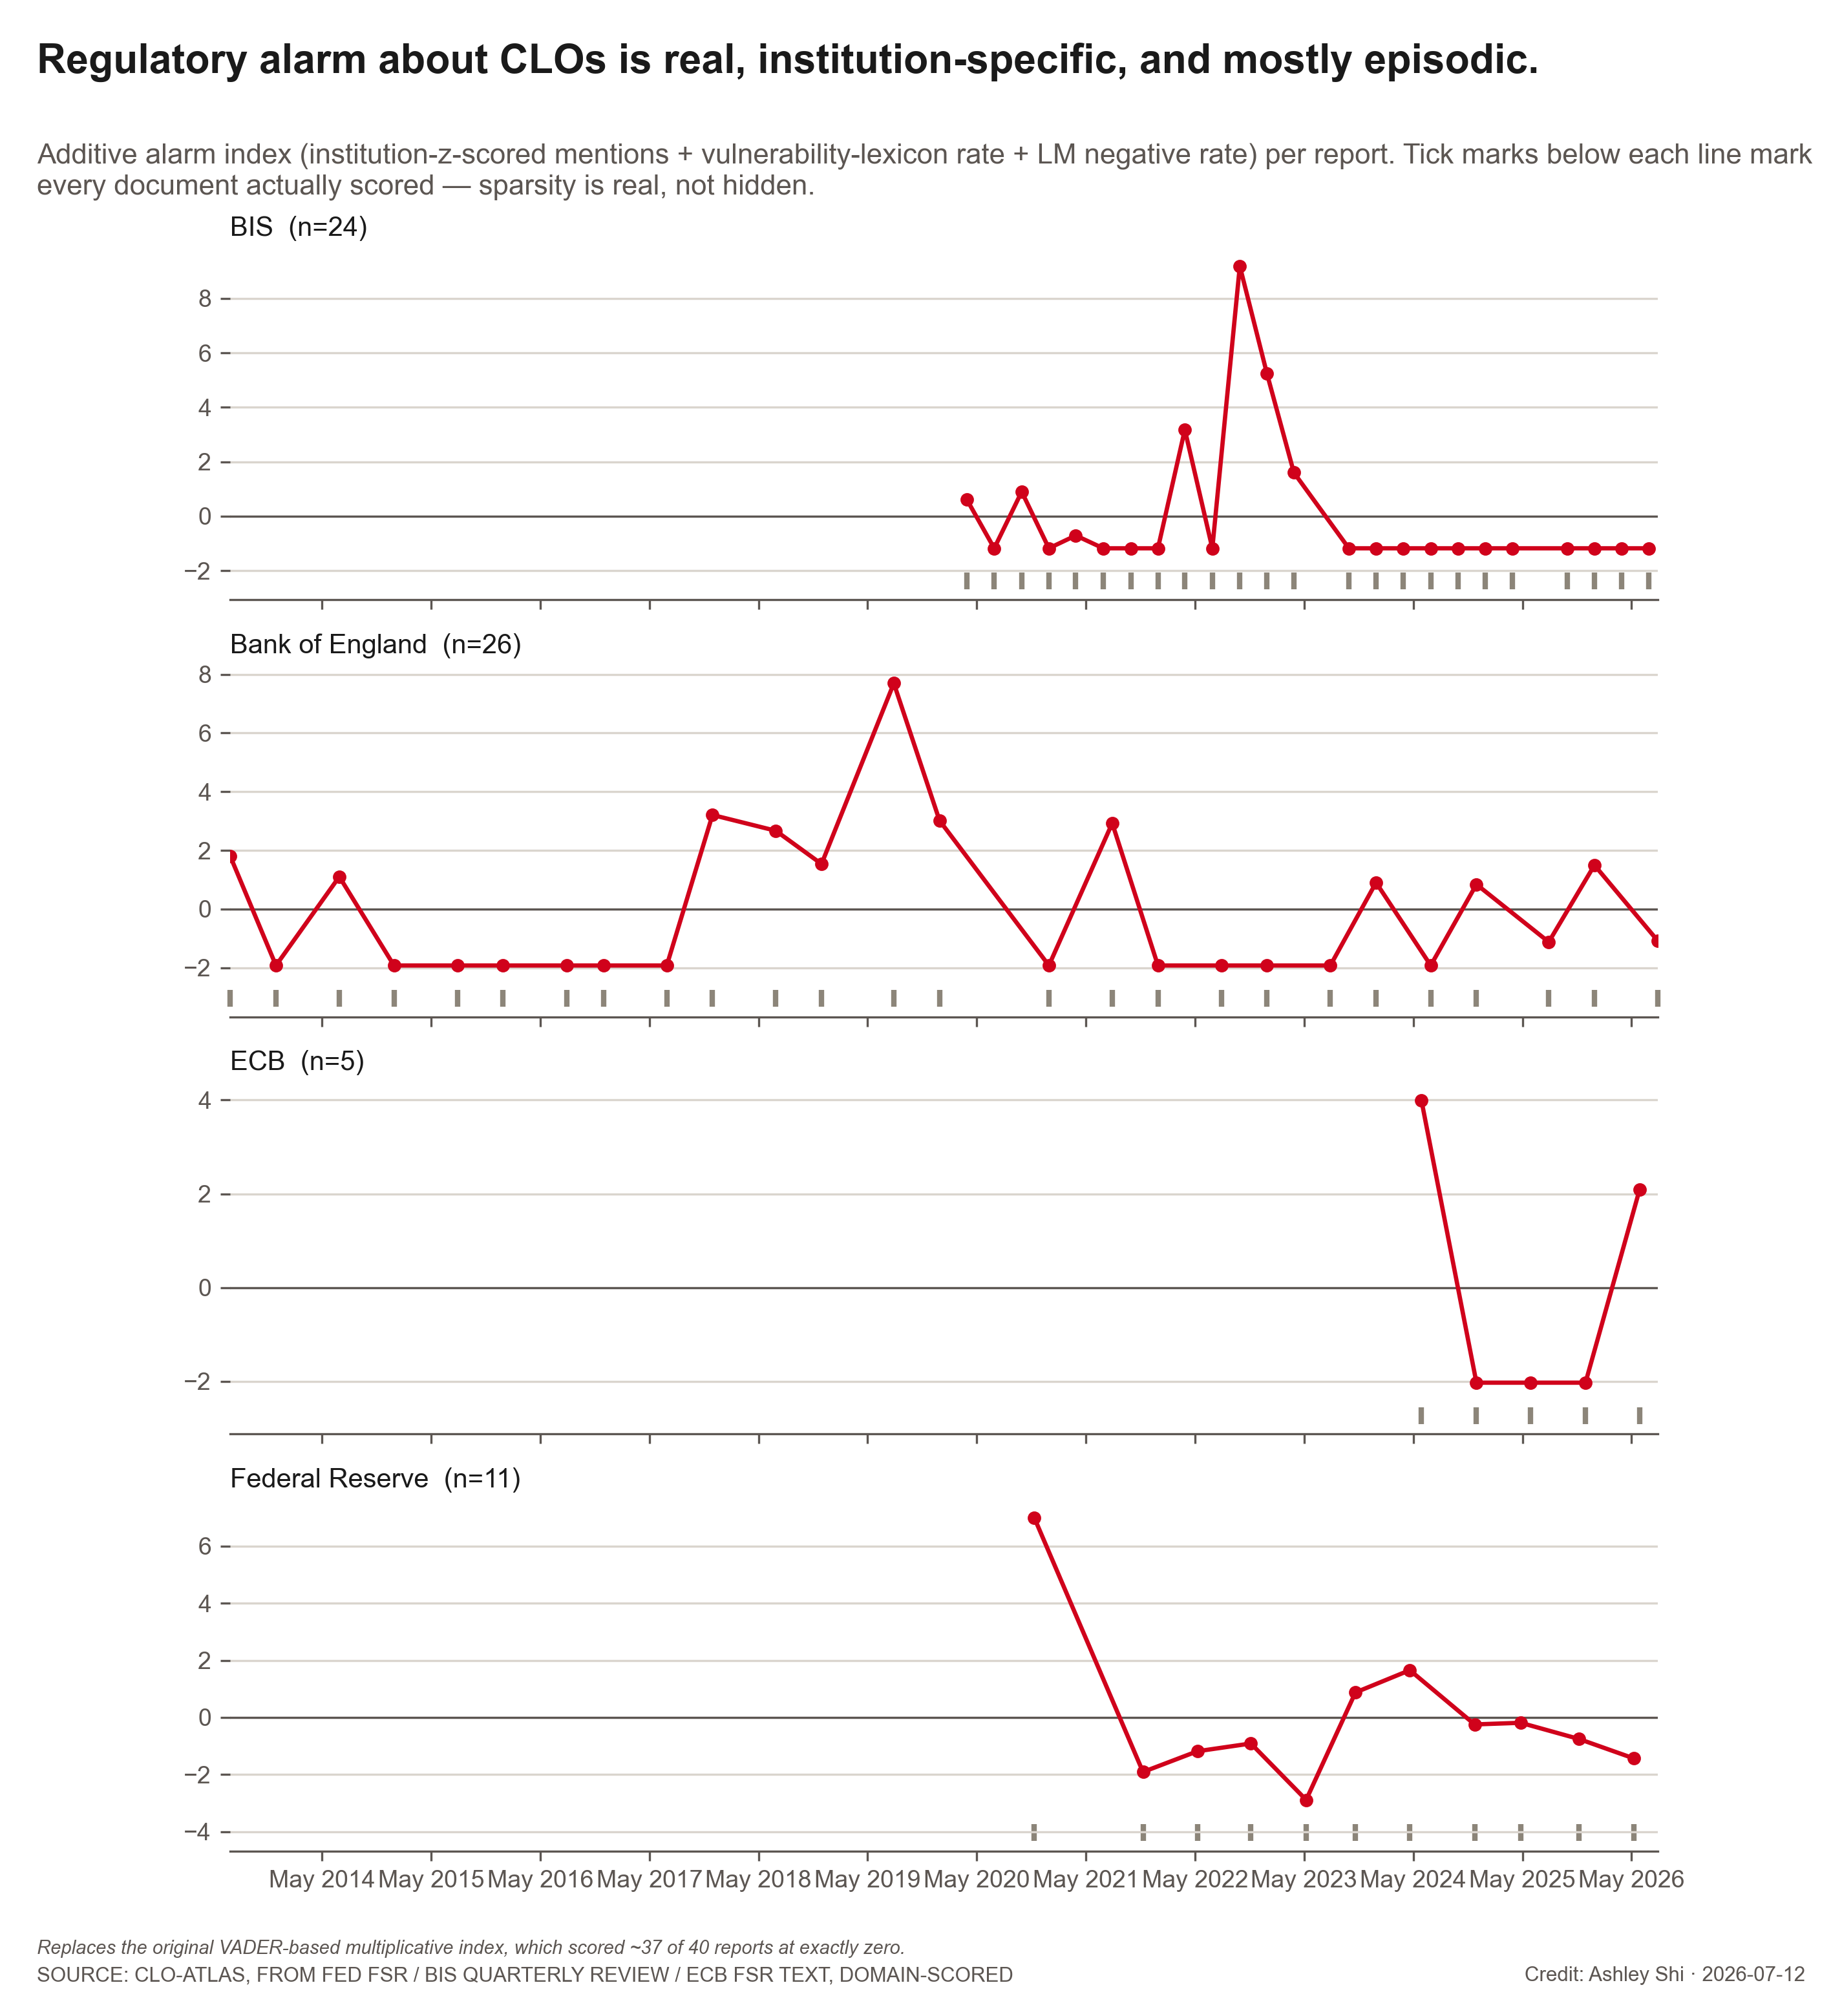

In [5]:
path = pathlib.Path("../figures") / "viz_alarm_index_small_multiples.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_alarm_index_small_multiples")

Data: the rebuilt regulator corpus — 11 Fed Financial Stability Reports, 24 BIS Quarterly Reviews, 5 ECB Financial Stability Reviews, and 26 Bank of England Financial Stability Reports (66 documents across 4 institutions total, Bank of England newly added in `scrape_regulators_v2.py`) — scored by `analysis_alarm_v2.py`'s additive, institution-z-scored index (mention rate + vulnerability-lexicon rate + Loughran-McDonald negative rate). This replaces the original VADER-based multiplicative index, which scored 37 of the original 40 reports at exactly zero. **VERIFIED**.

Each panel is one institution's `alarm_index_v2` over time, with a zero reference line and a tick strip along the bottom marking every document actually scored, so sparse-coverage years stay visible instead of getting smoothed away. **VERIFIED**: the single highest-alarm report in the rebuilt index is the BIS's 2022-09-28 Quarterly Review, followed by the Bank of England's 2019-07-28 report and the Federal Reserve's November 2020 report.

This is the corrected version of the Section 6 headline chart — it shows regulatory alarm has real, institution-specific texture once measured with a domain-appropriate lexicon instead of a social-media-tuned one, which matters for how much weight the deck should put on "regulators are alarmed" as a claim about CLOs.

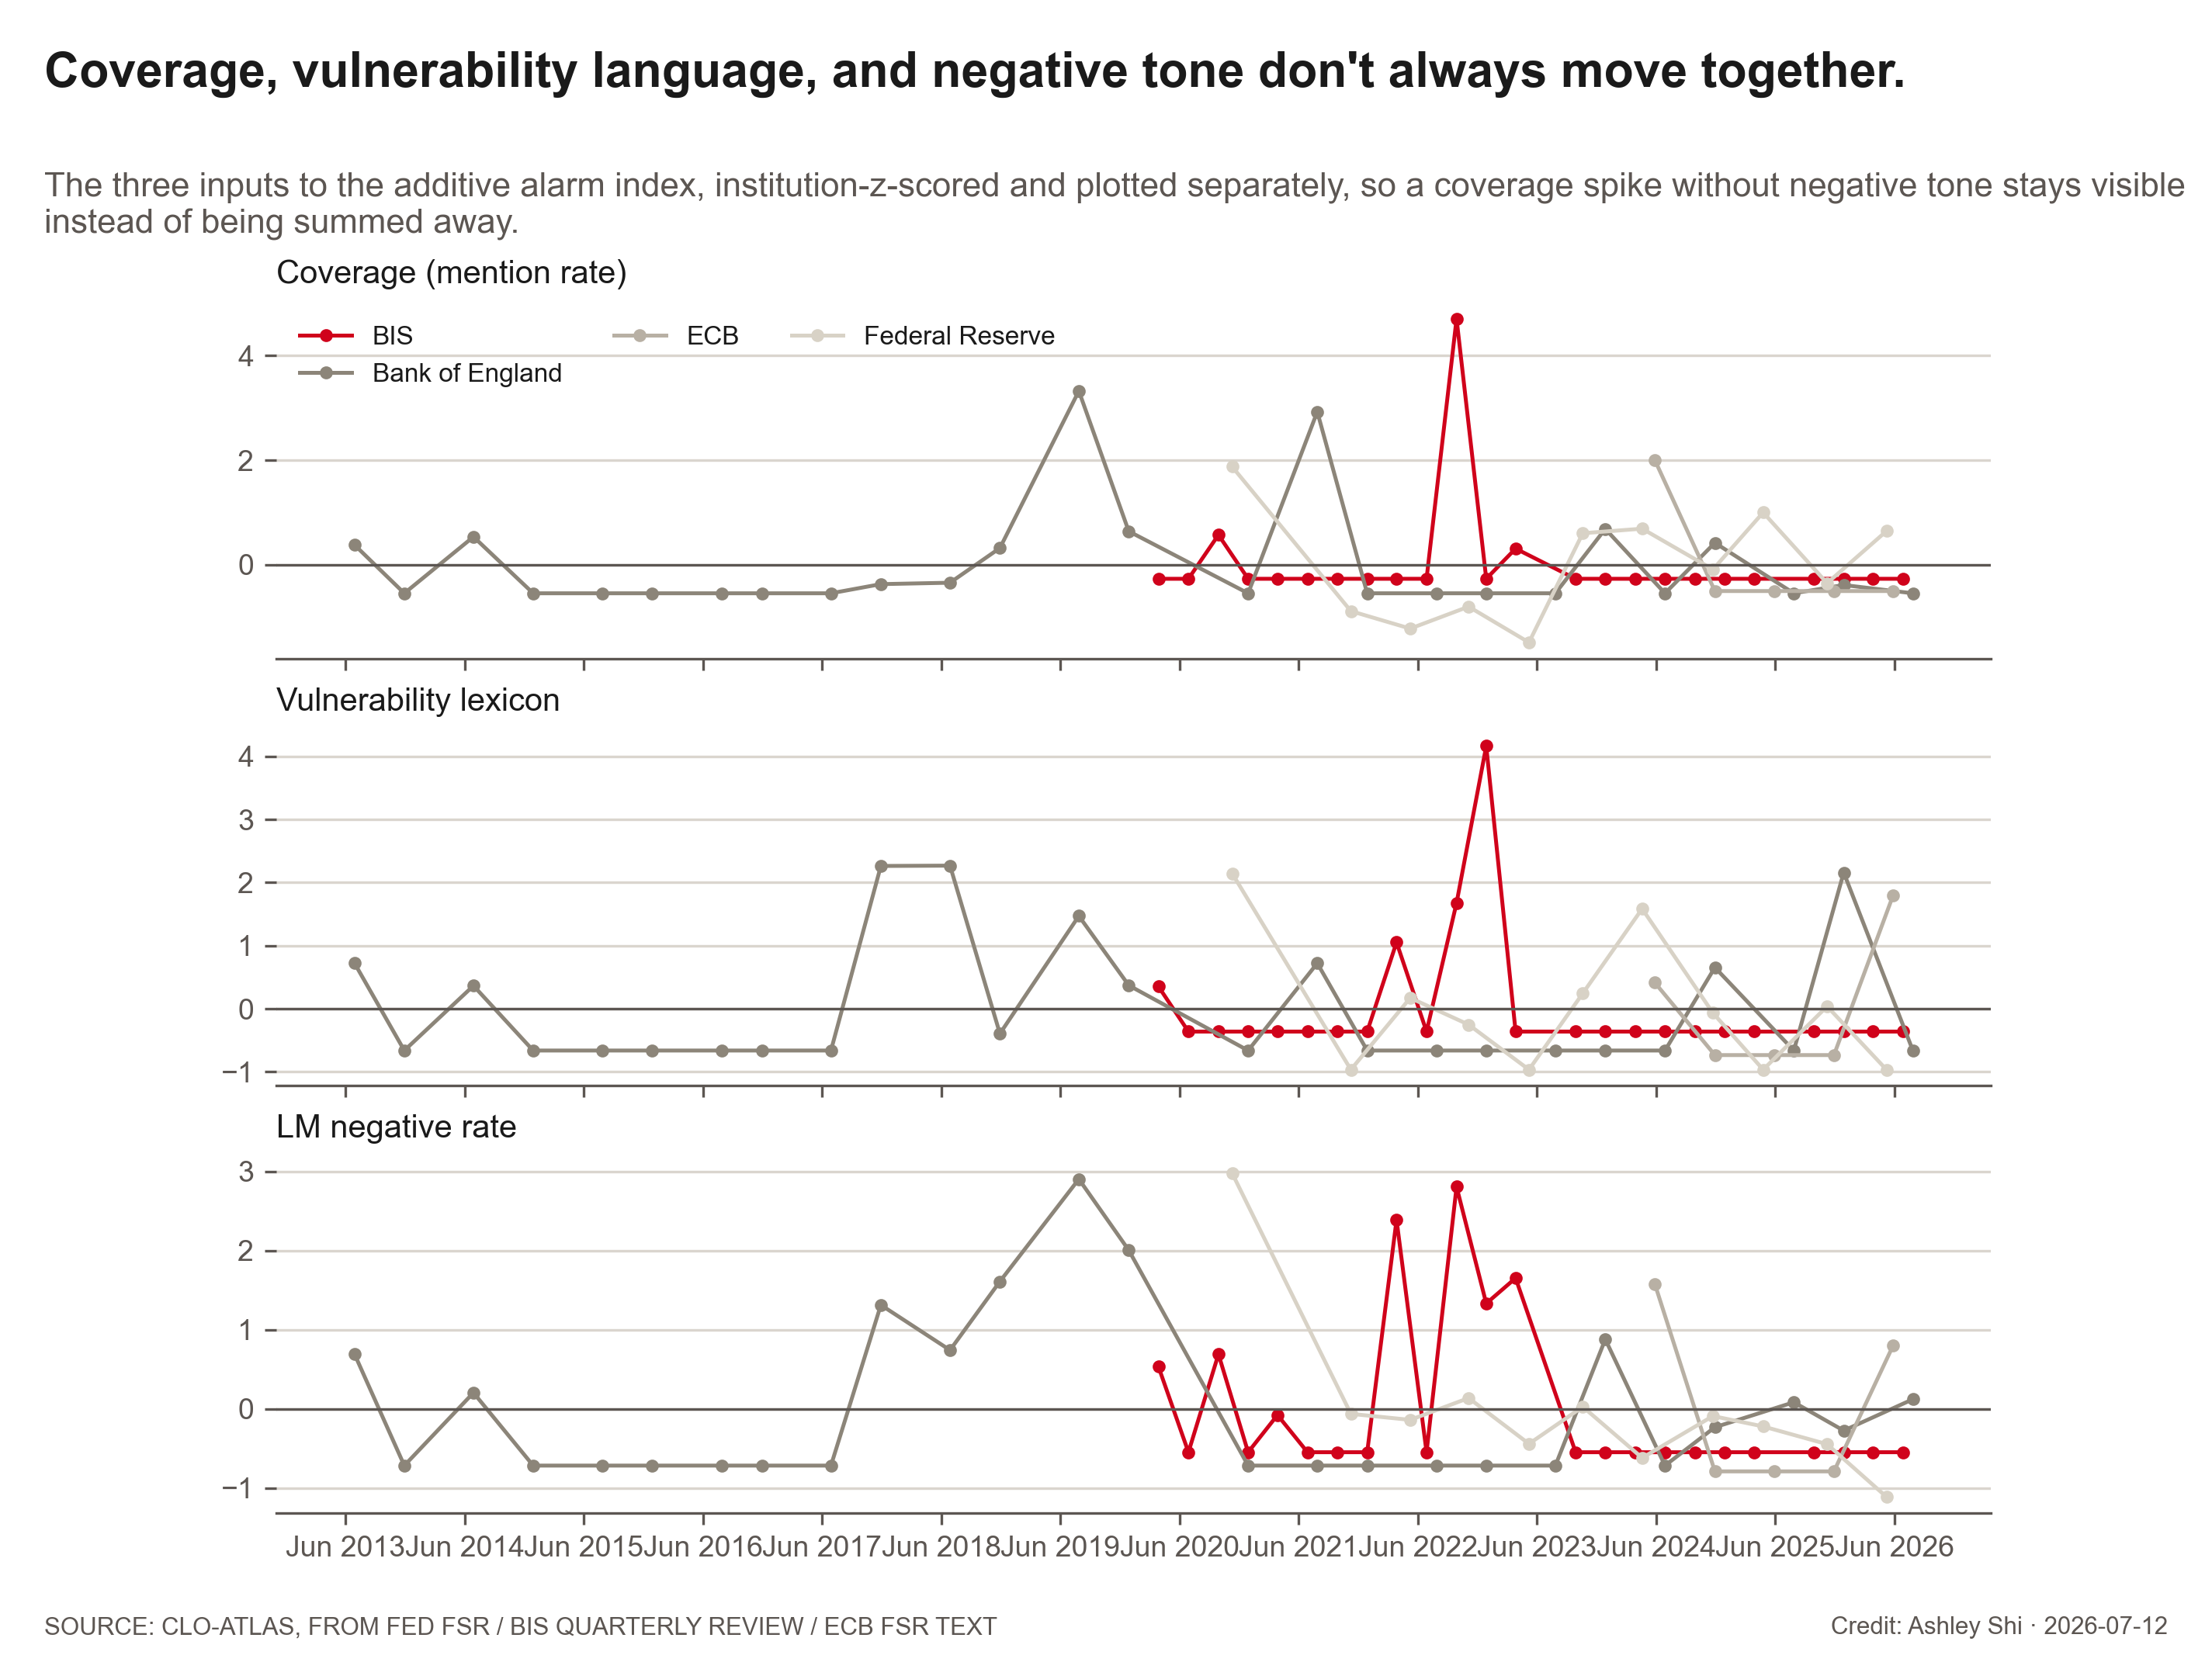

In [6]:
path = pathlib.Path("../figures") / "viz_alarm_components.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_alarm_components")

Data: the same `alarm_v2_by_report.parquet` output (66 reports, 4 institutions) behind the small-multiples panel above, but with its three additive inputs — z-scored mention rate, z-scored vulnerability-lexicon rate, and z-scored Loughran-McDonald negative rate — plotted separately by `viz_alarm_v2.viz_alarm_components`. **VERIFIED**.

Three stacked panels, one institution-line per panel, show coverage (how much a report talks about CLOs), vulnerability language (a hand-curated stress-related lexicon, `config.VULNERABILITY_STEMS`), and negative-lexicon tone as independent series rather than one summed number — the point visible on the chart is that a spike in one panel doesn't reliably co-occur with a spike in the other two.

For the asset-class narrative, this decomposition is the honesty check behind the headline alarm chart: it shows the index isn't just tracking how often CLOs get mentioned, and it lets a slide distinguish rising attention from rising concern rather than conflating the two.

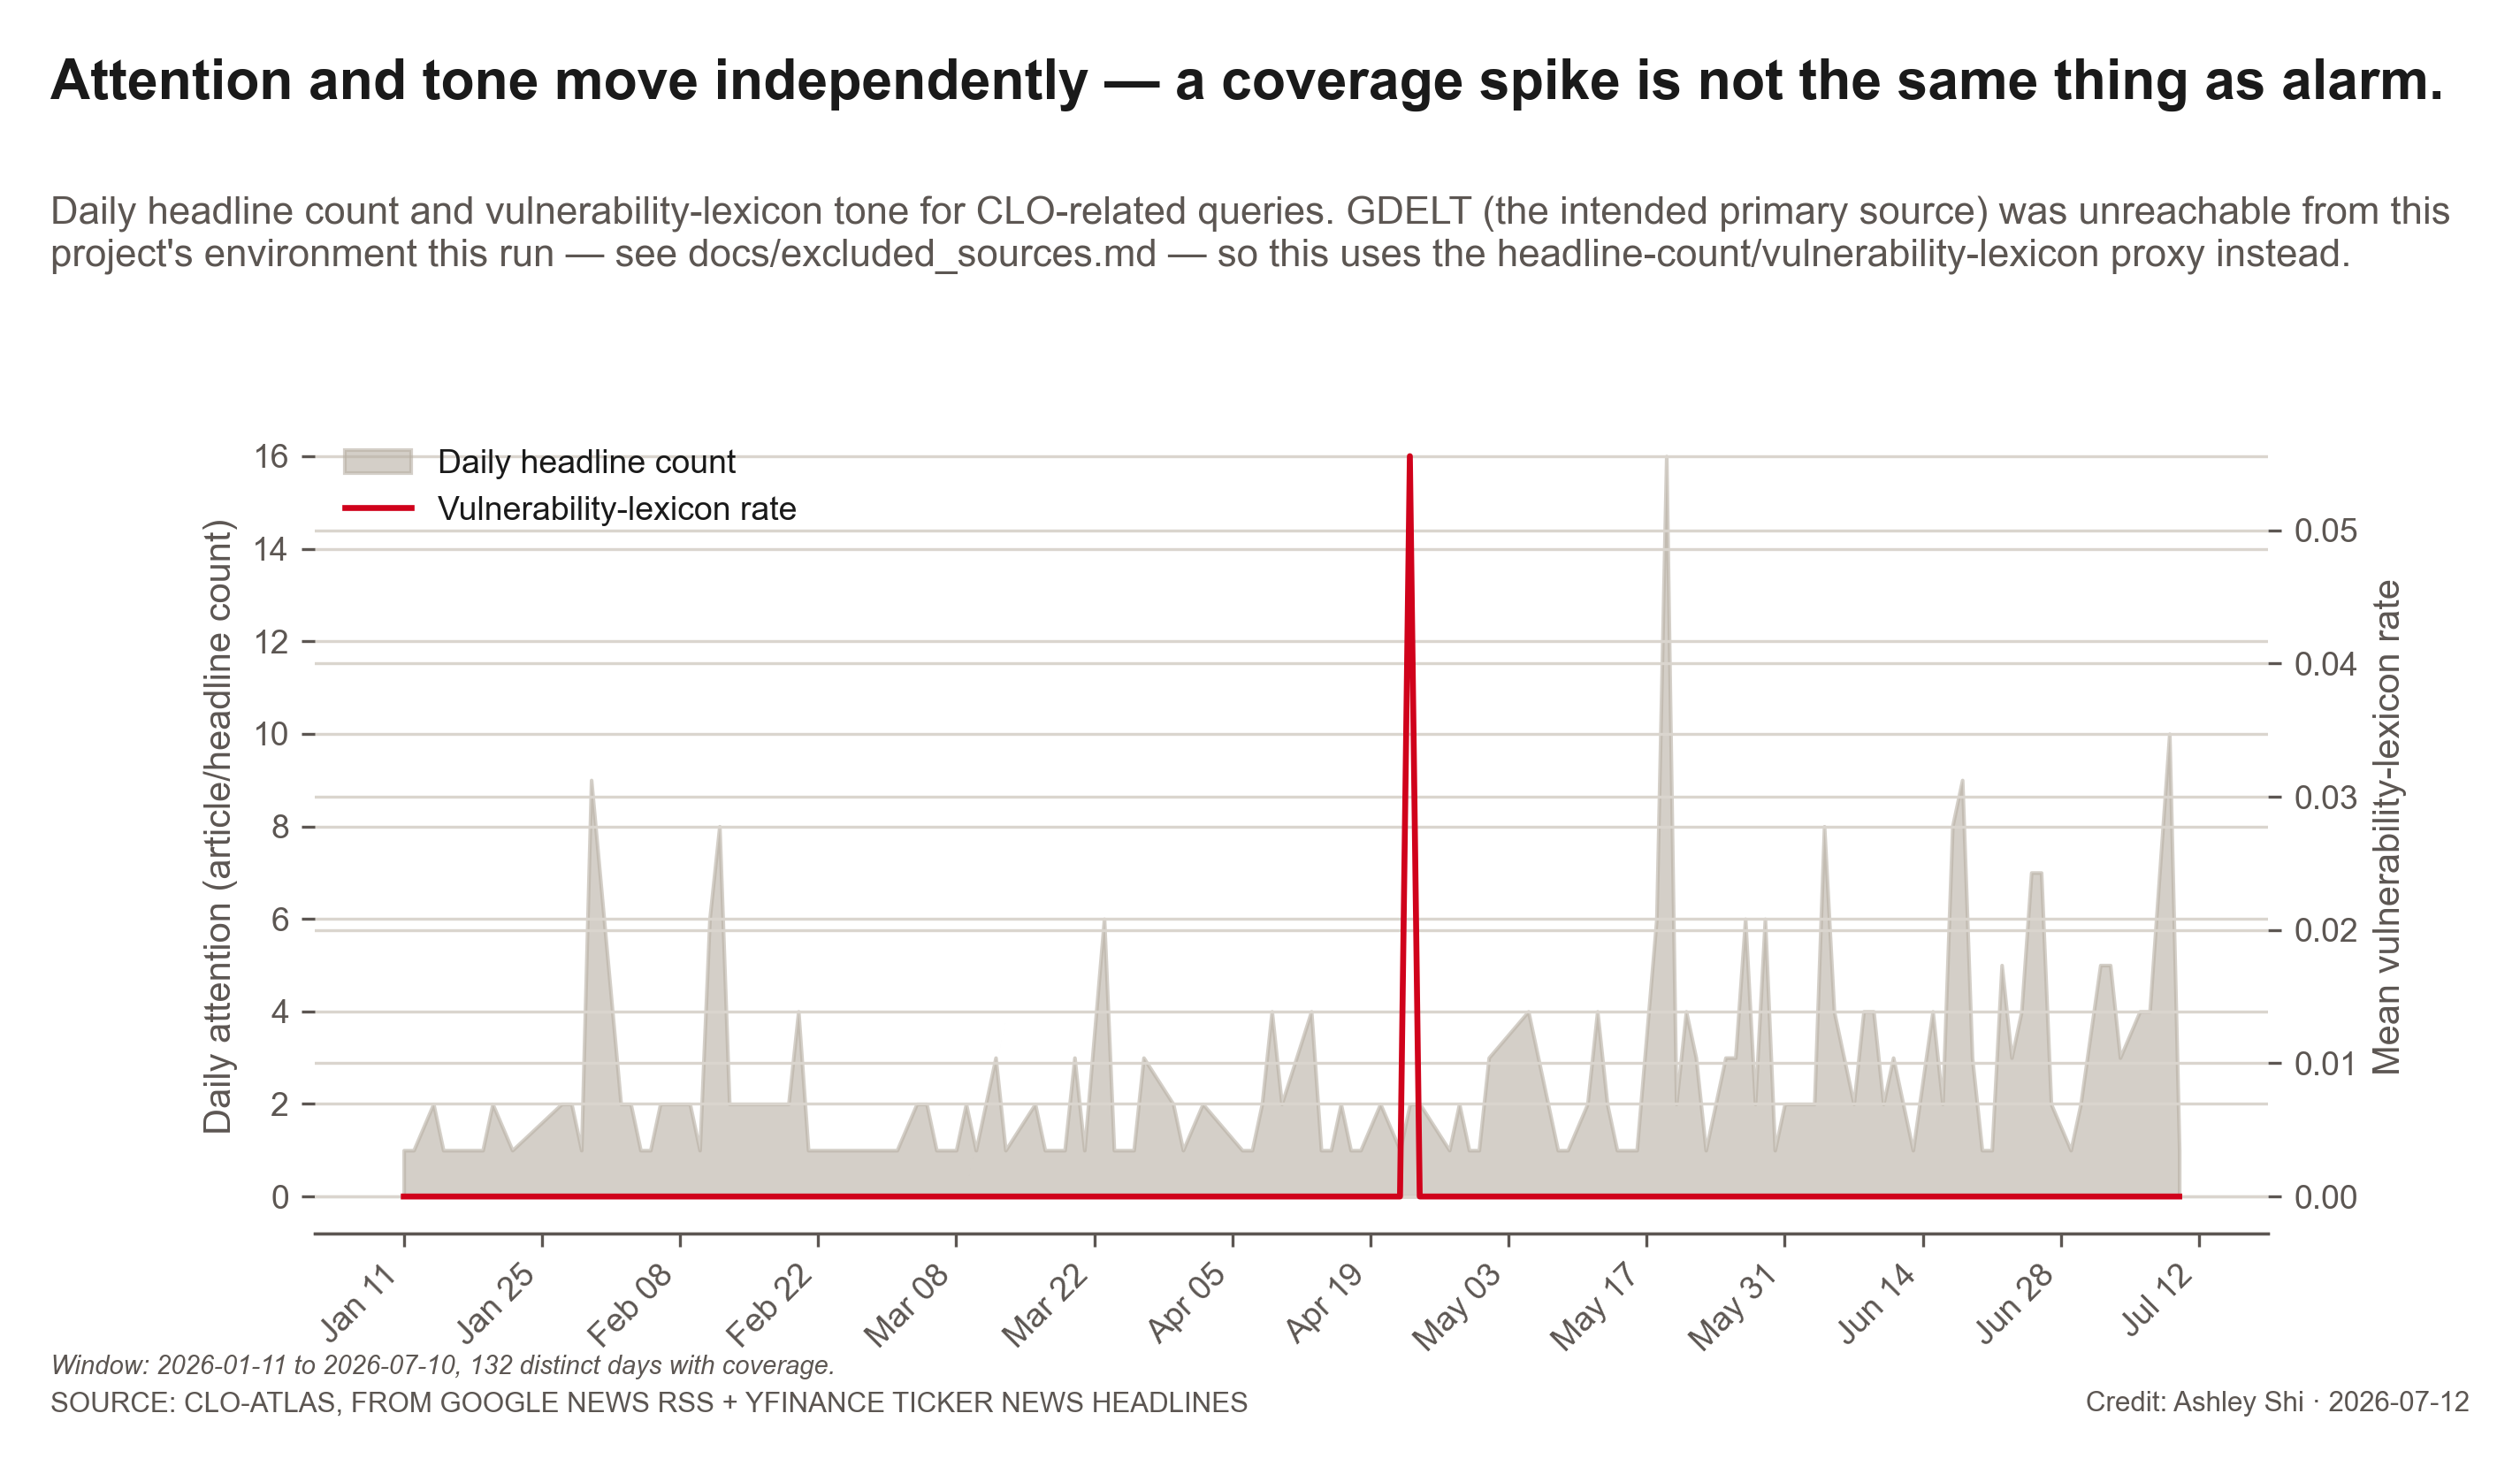

In [7]:
path = pathlib.Path("../figures") / "viz_attention_backbone.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_attention_backbone")

Data: Google News RSS and yfinance ticker-news headlines for CLO-related queries (`scrape_news_rss.py`, `scrape_yf_news.py`), domain-scored for a vulnerability-lexicon rate the same way regulator text is scored. GDELT (`scrape_gdelt.py`), the intended primary attention source, was persistently rate-limited (HTTP 429) from this project's sandboxed network even with full exponential backoff — logged in `docs/excluded_sources.md` and tagged **GAP — degraded gracefully** in this section's ledger — so the chart falls back to this headline proxy and says so in its own subtitle. The headline-proxy series actually plotted is **VERIFIED**.

The filled area is daily headline count (attention, left axis) and the line is mean vulnerability-lexicon rate (tone, right axis, accent color), zoomed to the densest recent ~180-day window out of 455 headlines across 212 distinct days total in the cache — the full history's older tail is too sparse to plot meaningfully.

This is the news-side counterpart to the regulator alarm index: it shows attention and tone moving independently in day-to-day coverage too, reinforcing that a busy news cycle about CLOs is not automatically a worried one — a useful caveat for any slide that cites headline volume as evidence of investor concern.

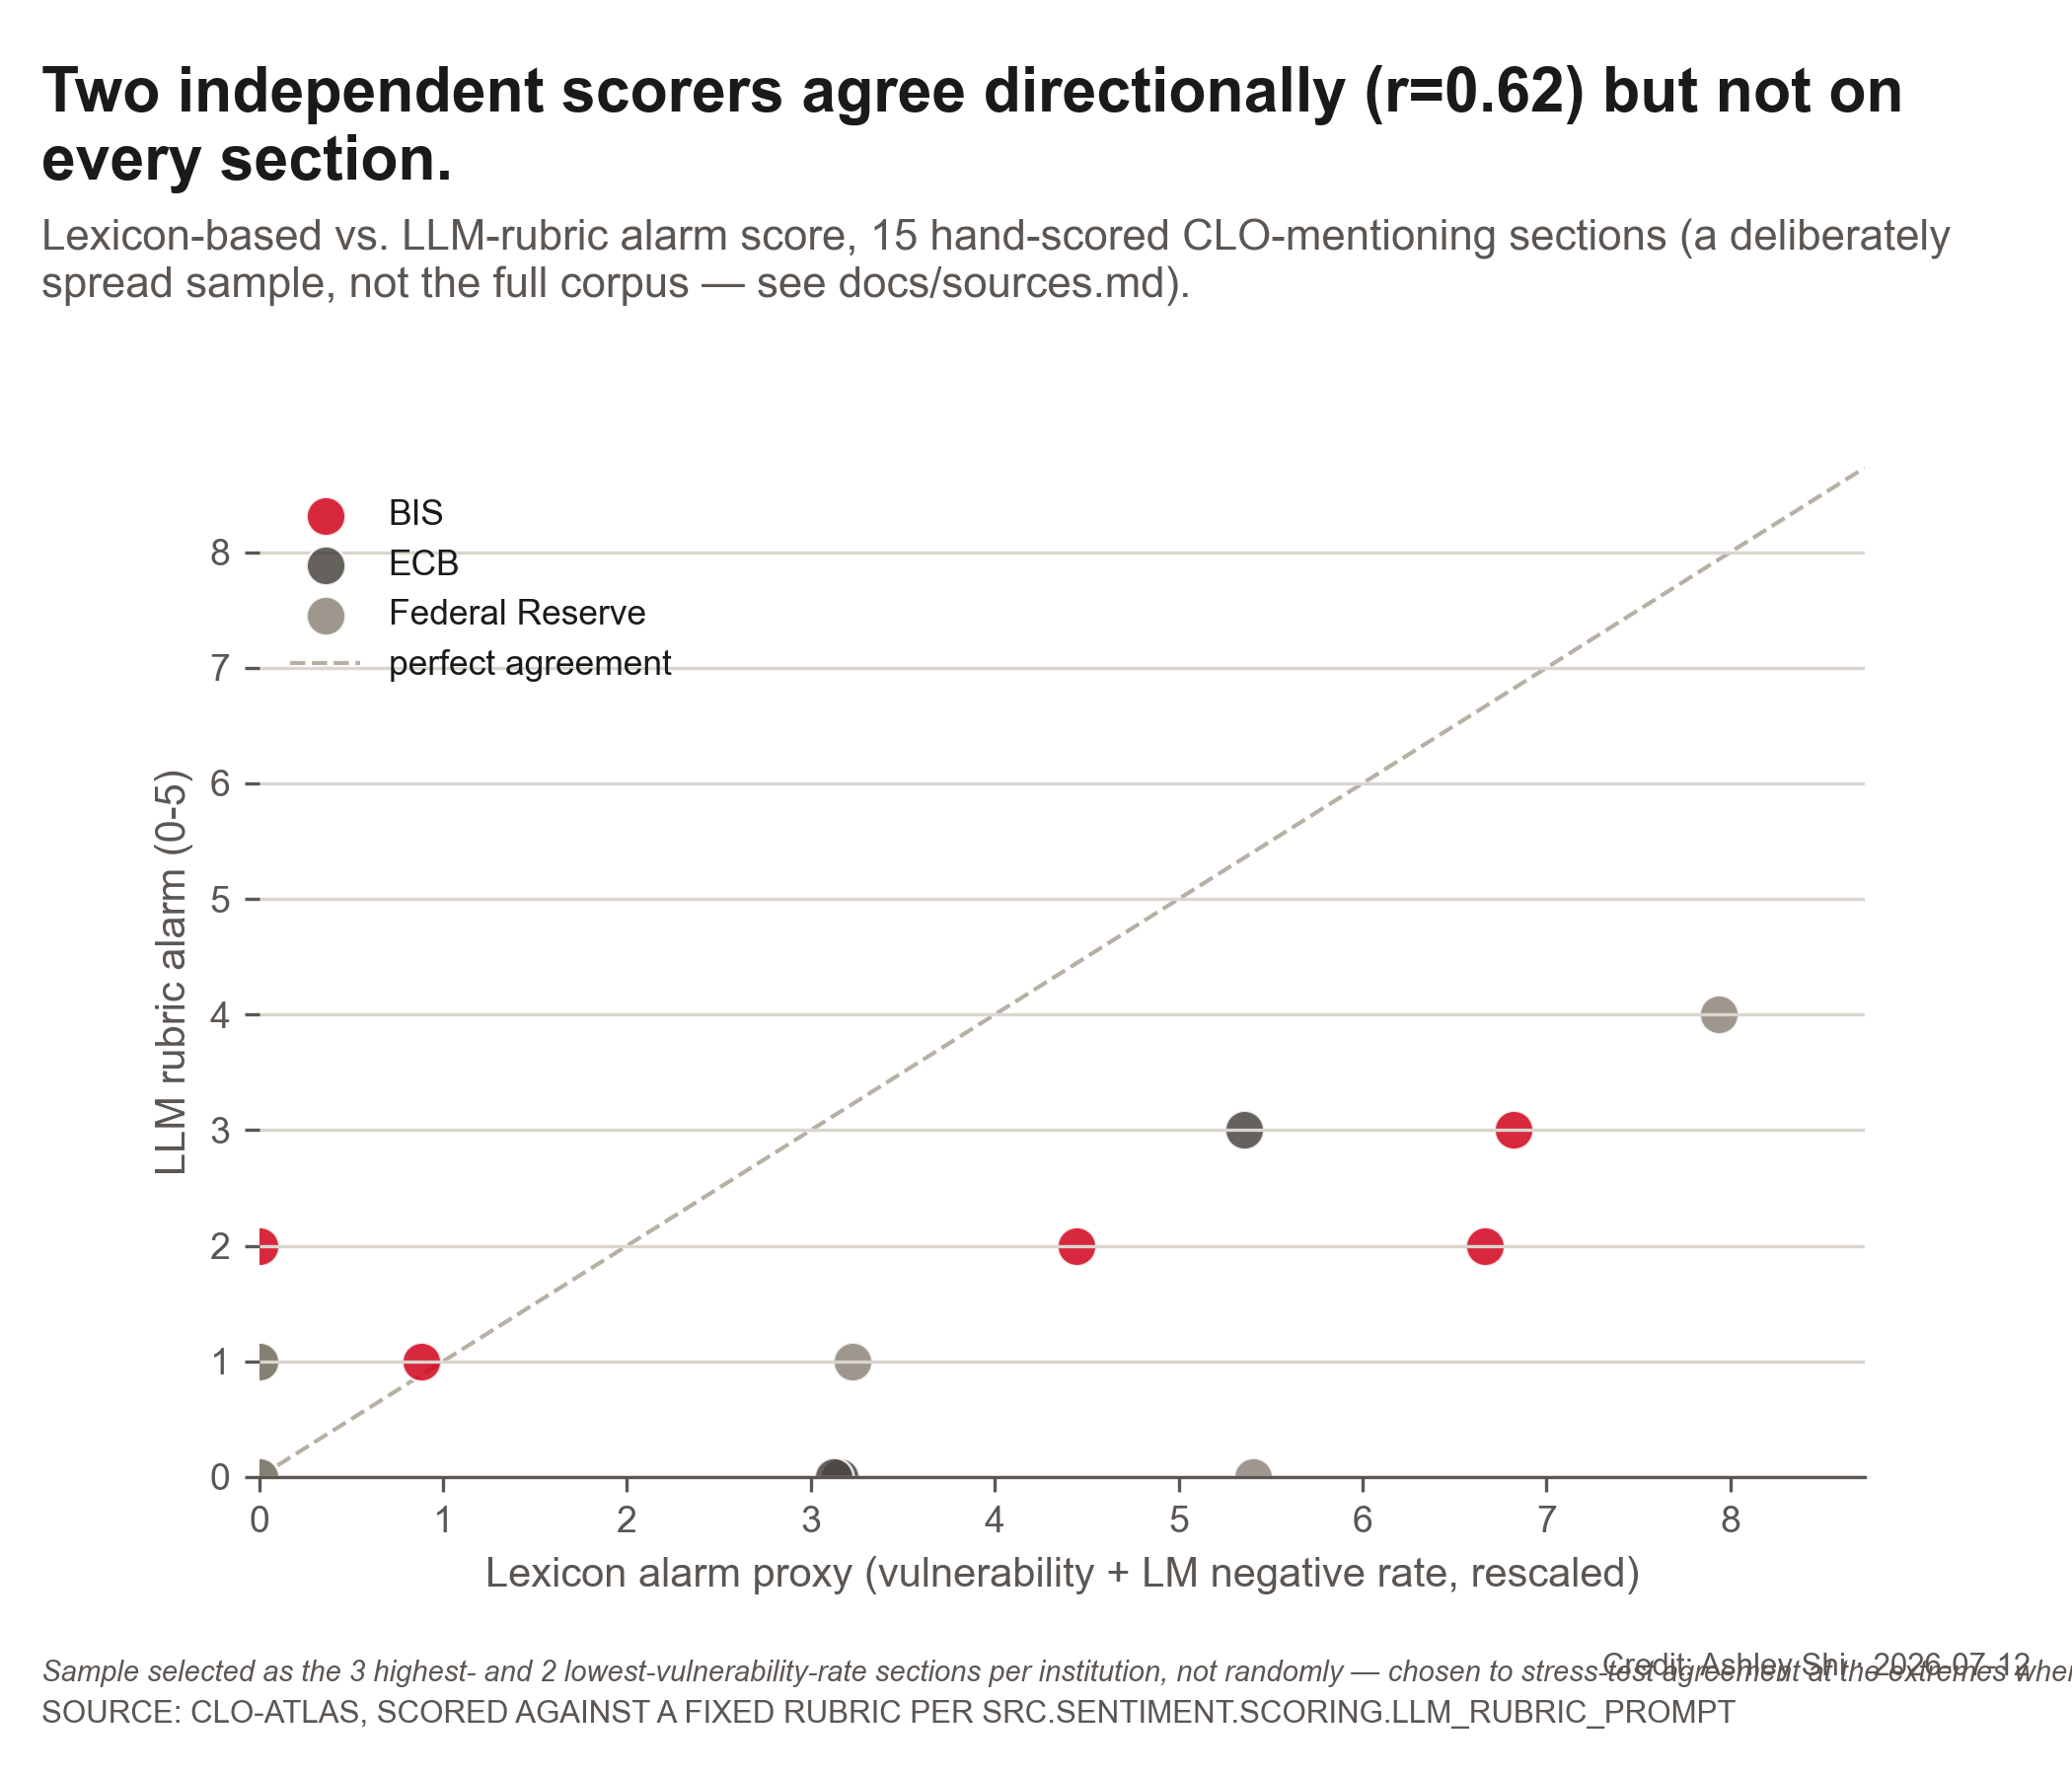

In [8]:
path = pathlib.Path("../figures") / "viz_scorer_agreement.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_scorer_agreement")

Data: a deliberately spread, hand-scored sample of 15 CLO-mentioning report sections (5 each from the Federal Reserve, BIS, and ECB — the 3 highest- and 2 lowest-vulnerability-rate sections per institution), each scored two independent ways in `analysis_scorer_validation.py`: a deterministic lexicon score (vulnerability rate + LM negative rate, rescaled) and a fixed-rubric LLM judgment (0-5 alarm scale, cached by input hash). **VERIFIED**, with the sample size and selection method stated on the chart itself rather than implied.

The scatter plots lexicon score (x-axis) against LLM score (y-axis) per section, colored by institution, against a dashed line marking perfect agreement; the two scorers correlate at r=0.62 on this sample — directionally consistent but not tight agreement.

This is the methods-appendix honesty check behind every other alarm number in the deck: it quantifies how much the choice of scoring method (lexicon vs. LLM) could move an "alarm" reading, so a presentation citing this section's index can characterize it as a reasonable-but-imperfect measurement rather than ground truth.

## VERIFIED / TO-VERIFY ledger

Every number appearing in this section's exhibits, tagged `VERIFIED` (computed here) or `GAP` (a planned link/source that free data could not support, reported rather than dropped).

In [9]:
sentiment_v2_ledger = ledger.run()
sentiment_v2_ledger


,value,computation_or_citation,as_of,tag
0,66 regulator documents scored across 4 institu...,coverage_table(): document count by institutio...,n/a,VERIFIED
1,Additive alarm index has real variation across...,additive_alarm_index(): institution-z-scored m...,n/a,VERIFIED
2,"Highest-alarm report: BIS, 2022-09-28",alarm_index_v2 peak value in the rebuilt index,2022-09-28,VERIFIED
3,Lexicon-vs-LLM scorer correlation: r=0.62 on 1...,analysis_scorer_validation.py: hand-scored sam...,n/a,VERIFIED
4,GDELT attention/tone backbone: NOT AVAILABLE t...,Persistently rate-limited (429) from this proj...,n/a,GAP — degraded gracefully
5,455 headlines across 212 distinct days (news R...,analysis_attention_tone.headline_daily(),n/a,VERIFIED
6,2 CLO pricing announcements classified from th...,scrape_pressreleases.classify_pricing_announce...,n/a,VERIFIED
